In [8]:
# Importation des librairies générales
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importations des librairies pour le machine learning
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# chargement des données
X = pd.read_csv("data/X.csv",index_col=0)
y = pd.read_csv("data/y.csv",index_col=0)
print(y.columns)
y = y['QC_Conc_OGD'].astype(float)

In [86]:
categorical_columns = ['Technicien_id', 'Batch_KC8', 'Ref_plaque', 
       'Technicien_id.1',  'Centrifugation', 'Technicien_id.2', 'Lab_HR.2',
       'Lab_T.2', 'Technicien_id.3','month_production',  ]

numerical_columns = ['Vitesse_agitation',
       'Lab_HR', 'Lab_T', 'BaG_T', 'BaG_H2O_ppm', 'BaG_O2_ppm','Lab_HR.1', 'Lab_T.1', 'BaG_T.1', 'BaG_H2O_ppm.1',
       'BaG_O2_ppm.1', 'conc_KC8', 'volume_O2','days_exfo', 'sediment_time','exfo_gde_maree']


preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(),numerical_columns),
        ('categorical',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),categorical_columns)
    ]
)

In [4]:
pipeline = Pipeline([
('preprocessor',preprocessor),
('pca', KernelPCA(n_components=32, kernel='cosine')),  # Adjust n_components as needed
('classifier', LinearRegression())])

In [5]:
# helper fonction pour tester les algorithme de regression linéaire

def Test_algo(X,y,reduce_pca=True):

    all_res = pd.DataFrame()
    for _test_size in [0.1,0.2,0.3,0.4,0.5]:
        dummy = DummyRegressor()
        linear = LinearRegression()
        elastic = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=5000)
        sgd = SGDRegressor(max_iter=10000, tol=1e-3, loss='epsilon_insensitive',penalty='elasticnet')
        forest = RandomForestRegressor(max_depth=10,max_features='log2',min_samples_split=20)

        for model in [dummy, linear,elastic,sgd,forest]:

            if reduce_pca == True:
                pipeline = Pipeline([
        ('preprocessor',preprocessor),
        ('pca', KernelPCA(n_components=32, kernel='cosine')),  # Adjust n_components as needed
        ('regressor', model)])
            else:
                pipeline = Pipeline([
        ('preprocessor',preprocessor),
        ('regressor', model)])
            pipe = pipeline
            cv = cross_validate(pipe,X,y,cv=ShuffleSplit(n_splits=5,test_size=_test_size),return_train_score=True)
            results = pd.DataFrame(cv)

            # dataprep pour plot
            res = pd.DataFrame()
            res["score"] = results['train_score'].values
            res['type'] = 'train'
            res['model'] = str(model)[:20]
            res['test_size'] = _test_size
            all_res = pd.concat([all_res,res])
            res = pd.DataFrame()
            res["score"] = results['test_score'].values
            res['type'] = 'test'
            res['model'] = str(model)[:20]
            res['test_size'] = _test_size
            all_res = pd.concat([all_res,res])

    return all_res


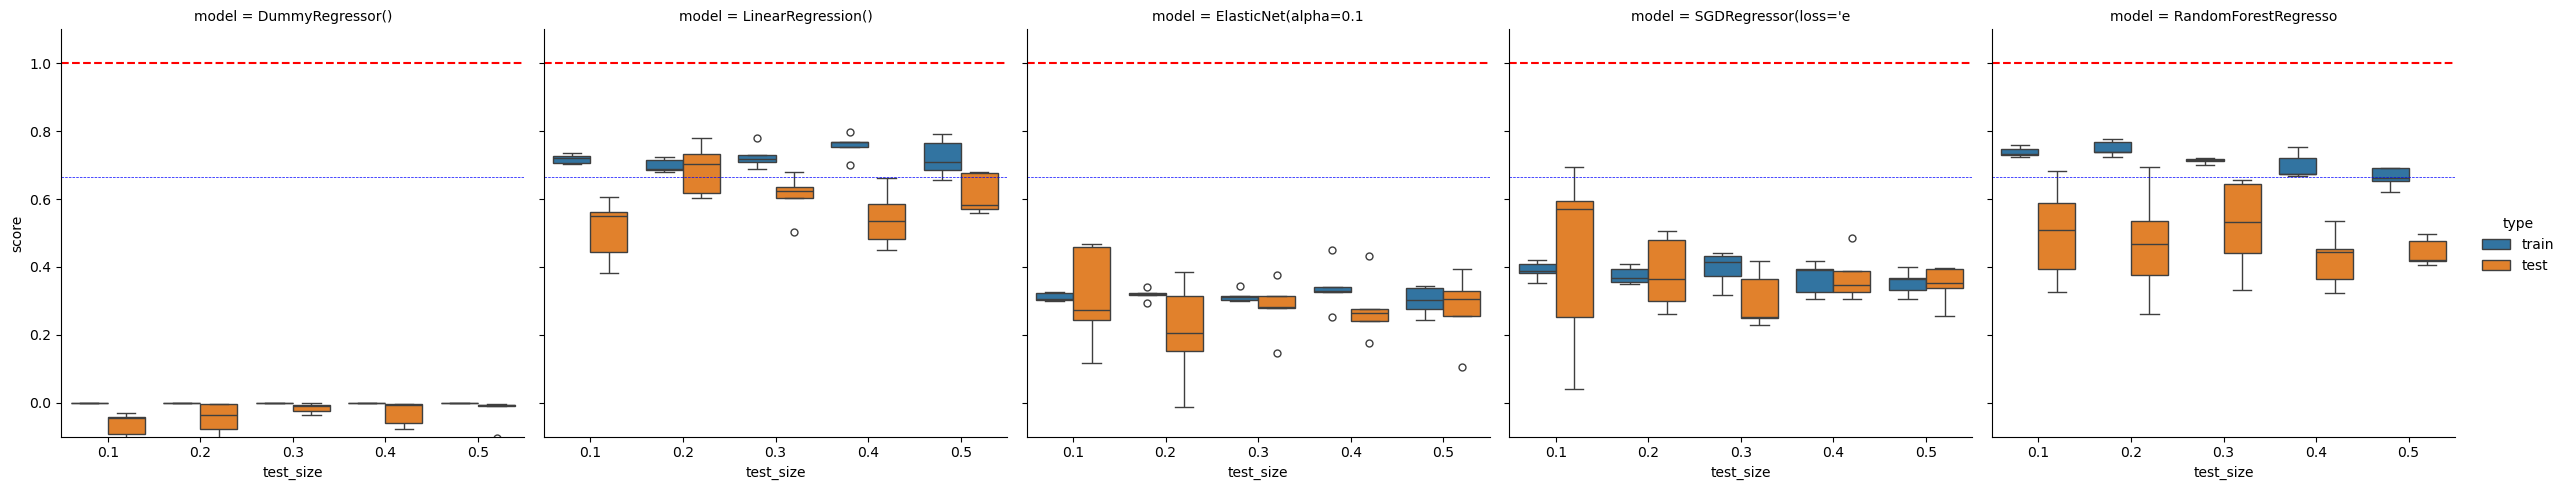

In [6]:
all_res = Test_algo(X,y)

g = sns.catplot(data=all_res,
        kind='box',
        x='test_size',
        y='score',
        hue='type',
        col='model')

for ax in g.axes.flatten():
    ax.axhline(y=1, linestyle='--', color='red')
    ax.axhline(y=0.666, linestyle='--', lw=0.5,color='b')

plt.ylim([-0.1,1.1])
plt.show()

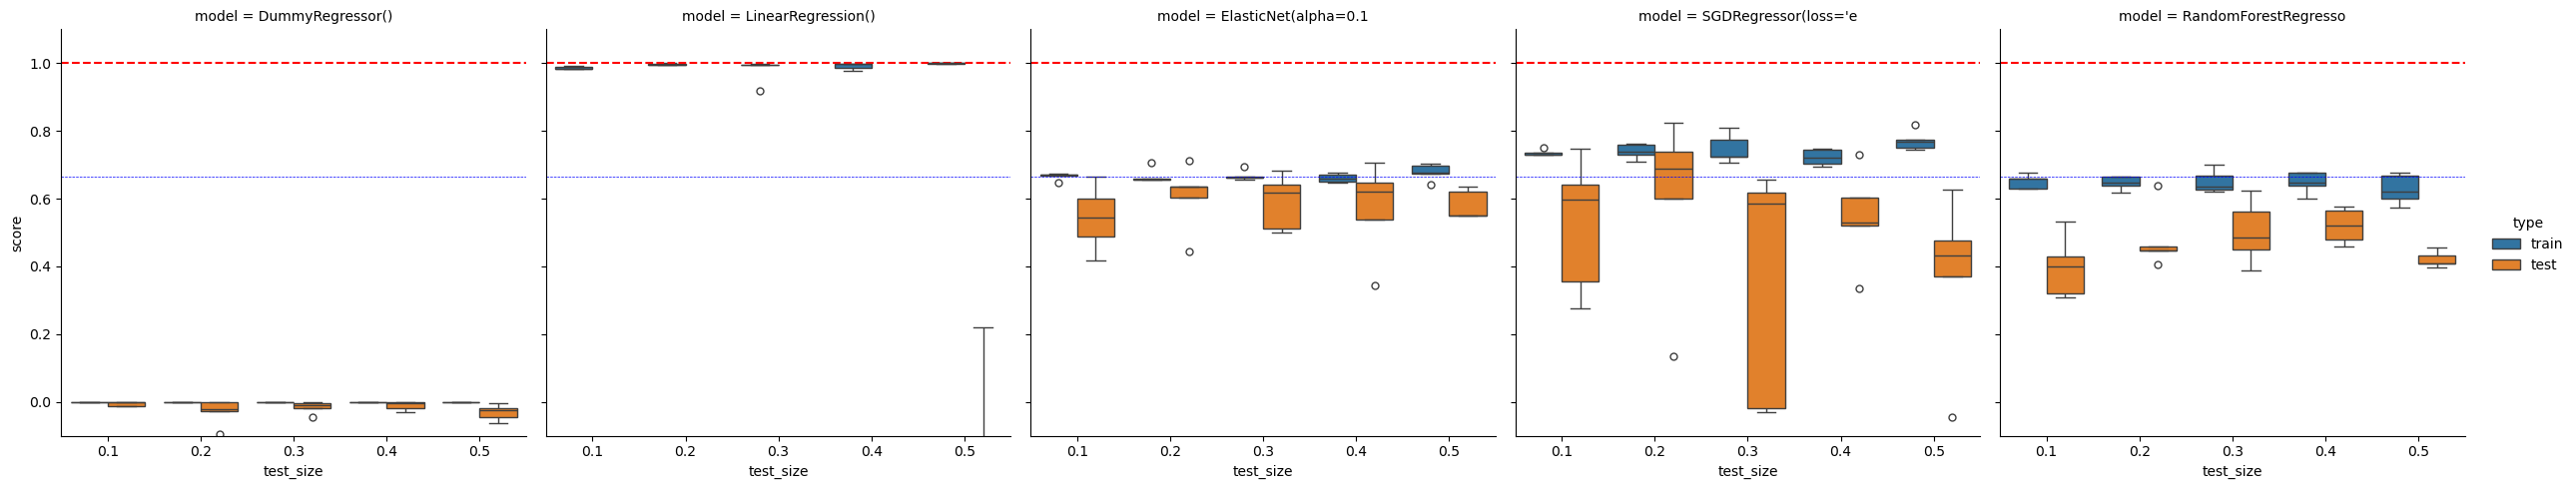

In [7]:

all_res = Test_algo(X,y, reduce_pca=False)

g = sns.catplot(data=all_res,
        kind='box',
        x='test_size',
        y='score',
        hue='type',
        col='model')

for ax in g.axes.flatten():
    ax.axhline(y=1, linestyle='--', color='red')
    ax.axhline(y=0.666, linestyle='--', lw=0.5,color='b')

plt.ylim([-0.1,1.1])
plt.show()

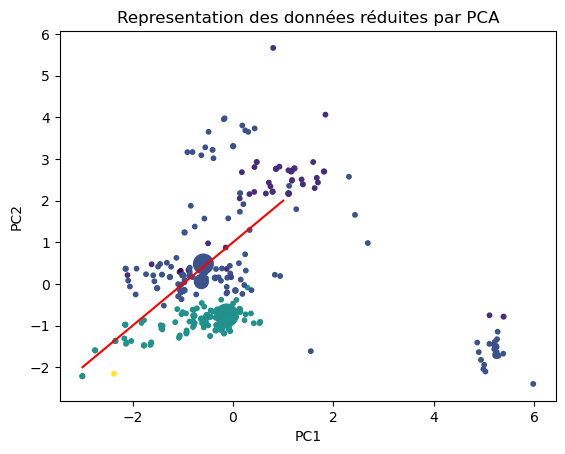

In [8]:
pca = KernelPCA(n_components=2)
weights = pca.fit_transform(preprocessor.fit_transform(X))


colors = X.conc_KC8.values
colors_normalized = (colors - np.min(colors)) / (np.max(colors) - np.min(colors))
cmap = plt.colormaps['viridis']  
colors_mapped = cmap(colors_normalized)

# plt.scatter(weights[:, 0], weights[:, 1], c=colors_mapped,s=X.Centrifugation*20+10)
# plt.scatter(weights[:, 0], weights[:, 1], c=colors_mapped,s=X.days_exfo**0.5)
plt.scatter(weights[:, 0], weights[:, 1], c=colors_mapped,s=X.exfo_gde_maree**1.5+10)



plt.plot([-3,1],[-2,2],c='red')
plt.title("Representation des données réduites par PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [9]:
# lr = LinearRegression()
# pca = KernelPCA(n_components=32)
# lr.fit(X,y)
# plt.bar(x = range(X.shape[1]), height=lr.coef_)
# plt.xlabel("id des paramètres utilisés pour la régression")

In [10]:
# en = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=5000)
# en.fit(X.iloc[:,:-1],y)

In [11]:
# [en.coef_ != 0]

In [12]:
# plt.figure( figsize=(3,4))
# plt.barh(y=X.iloc[:,:-1].columns[en.coef_ != 0],width=en.coef_[en.coef_ != 0])
# plt.title("Coefficient des paramatres != 0")

In [87]:
def set_preprocessor(X):
    """this function instanciate and test a sklearn preprocessor"""
    categorical_columns = ['Technicien_id', 'Batch_KC8', 'Ref_plaque', 
       'Technicien_id.1',  'Centrifugation', 'Technicien_id.2', 'Lab_HR.2',
       'Lab_T.2', 'Technicien_id.3','month_production',  ]

    numerical_columns = ['Vitesse_agitation',
        'Lab_HR', 'Lab_T', 'BaG_T', 'BaG_H2O_ppm', 'BaG_O2_ppm','Lab_HR.1', 'Lab_T.1', 'BaG_T.1', 'BaG_H2O_ppm.1',
        'BaG_O2_ppm.1', 'conc_KC8', 'volume_O2','days_exfo', 'sediment_time','exfo_gde_maree']

    preprocessor = ColumnTransformer(
        transformers=[
            ('numerical', StandardScaler(),numerical_columns),
            ('categorical',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),categorical_columns)])
    try:
        preprocessor.fit(X)
        return preprocessor
    except:
        return ("set_preprocessor is not working, check columns names")

# reload X because better columns preprocessing
X = pd.read_csv("data/X.csv",index_col=0)

preprocessor = set_preprocessor(X)
X=preprocessor.transform(X)



# grid search cv for elastic net

In [ ]:
from sklearn.linear_model import ElasticNetCV, ElasticNet

# cherche les meilleurs hyperparametres
cv_model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, .995, 1], eps=0.001, n_alphas=100, fit_intercept=True, 
                        precompute=True, max_iter=10000, tol=0.0001, cv=ShuffleSplit(n_splits=50,test_size=0.2), 
                        copy_X=True, verbose=0, n_jobs=-1, positive=False, random_state=42, selection='cyclic')
cv_model.fit(X,y)

print("best l1 ratio",cv_model.l1_ratio_)
print("best alpha",cv_model.alpha_)

# extract search data from mse_path

In [127]:
# Extract the MSE path
mse_path = cv_model.mse_path_
# Extract the alphas and l1_ratios used
alphas = [float(a) for a in cv_model.alphas_[0]] #cv_model.alphas_
l1_ratios = cv_model.l1_ratio
# Initialize a list to store the results
results = []
# Iterate over each combination of alpha and l1_ratio
for j, l1_ratio in enumerate(l1_ratios):
    for i, alpha in enumerate(alphas):
        # Calculate the mean MSE for this combination
        mean_mse = np.mean(mse_path[j, i, :])
        # Append the result to the list
        results.append({'alpha': alpha, 'l1_ratio': l1_ratio, 'mean_mse': mean_mse})

results_df = pd.DataFrame(results)
results_df

,alpha,l1_ratio,mean_mse
0,9.907560,0.1,2.418258
1,9.239824,0.1,2.407919
2,8.617091,0.1,2.393727
3,8.036328,0.1,2.378395
4,7.494706,0.1,2.362357
...,...,...,...
795,0.013097,1.0,1.344913
796,0.012215,1.0,1.373967
797,0.011391,1.0,1.404589
798,0.010624,1.0,1.433367


# cross validate with best params

best l1 ratio 1.0
best alpha 0.04931016160060395


/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_50307/1611963097.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cv['train_score'],cv['test_score']], labels=['train','test'])


Text(0.5, 1.0, 'Scores pour 50 splits')

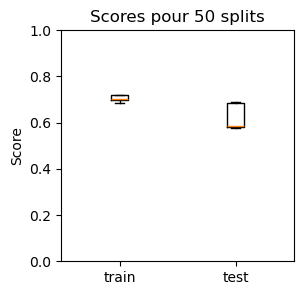

In [88]:
# mlflow.set_experiment("/Cross_validate_ElasticNet_v1")


# Cross-validation avec les meilleurrs hyperparametres
en = ElasticNet(alpha=cv_model.alpha_, l1_ratio=cv_model.l1_ratio_, fit_intercept=True, 
               precompute=True, max_iter=10000, tol=0.0001, 
               copy_X=True, positive=False, random_state=42, selection='cyclic')

cv = cross_validate(en,X,y,cv=ShuffleSplit(n_splits=5,test_size=0.2),return_train_score=True)

# affiche résultats
plt.figure(figsize=(3,3))
plt.boxplot([cv['train_score'],cv['test_score']], labels=['train','test'])
plt.ylim(0,1)
plt.ylabel('Score')
plt.title("Scores pour 50 splits")


## Plotting Cross-Validated Predictions

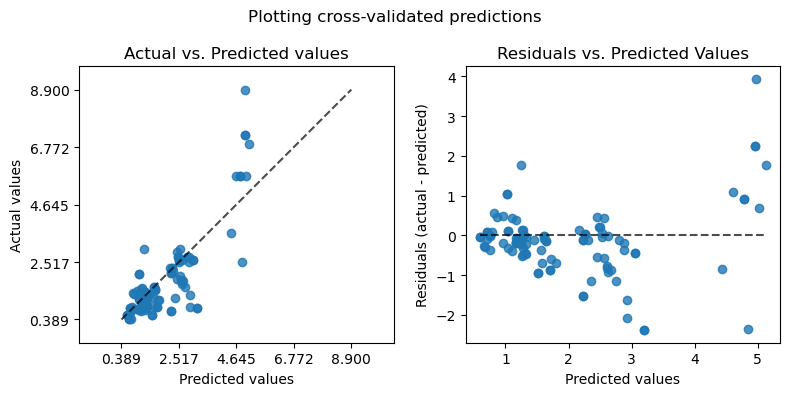

In [43]:

from sklearn.metrics import PredictionErrorDisplay
y_pred=en.fit_predict(X)
fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()

<BarContainer object of 9 artists>

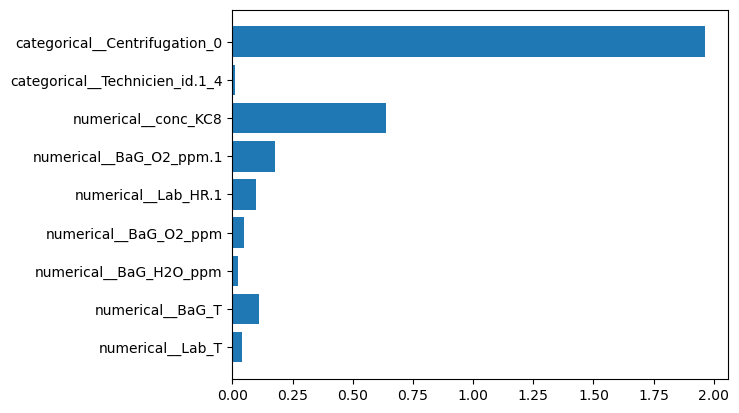

In [48]:
plt.barh(preprocessor.get_feature_names_out()[en.coef_>0], width=en.coef_[en.coef_>0])

In [83]:
import mlflow

mlflow.set_tracking_uri('http://127.0.0.1:8080')



In [ ]:
# saving model on MLFLOW server
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("/Modele_ElasticNet_v1")

with mlflow.start_run() as run:
    mlflow.sklearn.log_model(
        sk_model=en, 
        input_example = X,
        registered_model_name = "2025_02_ElasticNetModel_for_OGD_cond_v1",
        artifact_path='Carbon_waters_2025_02_27')


In [74]:
run.info

<RunInfo: artifact_uri='file:///Users/remicazelles/Documents/Travail/2023-SImplon_microsoft/PROJET_FINAL/ML_supervized/mlflow_000/461675028157204034/bba0dea982254019a77d101e712ae2aa/artifacts', end_time=None, experiment_id='461675028157204034', lifecycle_stage='active', run_id='bba0dea982254019a77d101e712ae2aa', run_name='nebulous-mouse-684', run_uuid='bba0dea982254019a77d101e712ae2aa', start_time=1741860982030, status='RUNNING', user_id='remicazelles'>

In [ ]:
# saving model on Azure


# save model on mlflow


mlflow server --backend-store-uri sqlite:///Carbon_waters_models_optimization.db --host 127.0.0.1 --port 8080   

In [ ]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("/Carbon_waters_Saving_pipeline_linear_model")


model = Pipeline([
                ('pca', KernelPCA(n_components=32, kernel='cosine')), 
                ('regressor', LinearRegression())
                ])

model.fit(X,y)

with mlflow.start_run():
    mlflow.sklearn.log_model(
        sk_model=model, 
        input_example = pd.DataFrame(X.iloc[66,:]).T,
        registered_model_name = "2024_12_linear_model_for_OGD_cond_v1",
        artifact_path='Carbon_waters_2021_12_1')


Registered model '2024_12_linear_model_for_OGD_cond_v1' already exists. Creating a new version of this model...
2024/12/20 12:39:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: 2024_12_linear_model_for_OGD_cond_v1, version 3


🏃 View run debonair-hawk-86 at: http://127.0.0.1:8080/#/experiments/4/runs/d6ded4028a6a45f9a80afa37d2a5f020
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/4


Created version '3' of model '2024_12_linear_model_for_OGD_cond_v1'.


In [ ]:
mlflow.end_run()

# new model with less variables

In [ ]:
# to_remove_idx = list()
# for i in range(weights.shape[0]):
#     if (weights[i,0] < -3.5) or (weights[i,1] > 2.1):
#         to_remove_idx.append(i)

# to_keep_idx = [a for a in range(weights.shape[0]) if a not in to_remove_idx]

In [ ]:
# X_opt = X.iloc[to_keep_idx,:]
# y_opt = y[to_keep_idx]

# all_res = Test_algo(X_opt,y_opt)

# g = sns.catplot(data=all_res,
#         kind='box',
#         x='test_size',
#         y='score',
#         hue='type',
#         col='model')

# for ax in g.axes.flatten():
#     ax.axhline(y=1, linestyle='--', color='red')
#     ax.axhline(y=0.666, linestyle='--', lw=0.5,color='b')

# plt.ylim([-0.1,1.1])
# plt.show()

mlflow server --backend-store-uri sqlite:///my.db --host 127.0.0.1 --port 8080

In [ ]:
# def plot_data(all_res):
#     g = sns.catplot(data=all_res,
#             kind='box',
#             x='test_size',
#             y='score',
#             hue='type',
#             col='model')

#     for ax in g.axes.flatten():
#         ax.axhline(y=1, linestyle='--', color='red')
#         ax.axhline(y=0.666, linestyle='--', lw=0.5,color='b')

#     plt.ylim([-0.1,1.1])
#     plt.show()

# tracking model hyperparameter optimisation



### start mlflow server with connection to local bdd :

mlflow server --host 127.0.0.1 --port 8080  --backend-store-uri mysql+pymysql://<username>:<password>@localhost/<name_bdd>

MLFlow_track_experiments



In [ ]:
import itertools
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("/Carbon_waters_test_models_withPCA")


datasets = []
models = {
    'Dummy': DummyRegressor(),
    'Linear': LinearRegression(),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=5000),
    'SGD': SGDRegressor(max_iter=10000, tol=1e-3, loss='epsilon_insensitive', penalty='elasticnet'),
    'RandomForest': RandomForestRegressor(max_depth=10, max_features='log2', min_samples_split=20)
}


n_compo_values = [16, 32, 48, 64]
test_size_values = [0.1, 0.2, 0.3, 0.4, 0.5]

param_combinations = list(itertools.product(n_compo_values, test_size_values, models.items()))

all_res = pd.DataFrame()
for n_compo, test_size, (name, model) in param_combinations:
    with mlflow.start_run(nested=True):
        mlflow.log_param("model",name)
        mlflow.log_param("test_size",test_size)
        mlflow.log_param("PCs",str(n_compo))

        pipeline = Pipeline([
            ('pca', KernelPCA(n_components=n_compo, kernel='cosine')), 
            ('regressor', model)
            ])

        cv = cross_validate(pipeline,X,y,cv=ShuffleSplit(n_splits=20,test_size=test_size),return_train_score=True, scoring='neg_root_mean_squared_error')
        results = pd.DataFrame(cv)

        # dataprep pour plot
        res = pd.DataFrame()
        res["score"] = results['train_score'].values
        res['type'] = 'train'
        res['model'] = str(model)[:20]
        res['test_size'] = test_size
        res['n_components'] = n_compo
        all_res = pd.concat([all_res,res])
        res = pd.DataFrame()
        res["score"] = results['test_score'].values
        res['type'] = 'test'
        res['model'] = str(model)[:20]
        res['test_size'] = test_size
        res['n_components'] = n_compo

        all_res = pd.concat([all_res,res])

        mlflow.log_metric('train_mean',results['train_score'].values.mean())
        mlflow.log_metric('train_std',results['train_score'].values.std())
        mlflow.log_metric('test_mean',results['test_score'].values.mean())
        mlflow.log_metric('test_std',results['test_score'].values.std())



2025/02/27 13:45:37 INFO mlflow.tracking.fluent: Experiment with name '/Carbon_waters_test_models_withoutPCA' does not exist. Creating a new experiment.


🏃 View run thoughtful-doe-482 at: http://127.0.0.1:8080/#/experiments/2/runs/b2c5c8d7076a41f69e038845ad6c1907
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2
🏃 View run blushing-slug-882 at: http://127.0.0.1:8080/#/experiments/2/runs/698fbcf0e36949aabdda2af444b584d4
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2
🏃 View run glamorous-bee-261 at: http://127.0.0.1:8080/#/experiments/2/runs/be83c7890bcc475e8c44cc3fe68393fc
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2
🏃 View run bedecked-seal-346 at: http://127.0.0.1:8080/#/experiments/2/runs/74d7a591d17c4dfcb0ad4a95a951815c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2
🏃 View run charming-hound-412 at: http://127.0.0.1:8080/#/experiments/2/runs/9b6aa5f011af4a0d922bdad147aa9ceb
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2
🏃 View run capricious-asp-763 at: http://127.0.0.1:8080/#/experiments/2/runs/1420dbcca08243aba03c1960ca918b00
🧪 View experiment at: http://127.0.0.1:8080

# On enregistre le modele sur azure

In [ ]:
X = X.iloc[:,:-1]

In [13]:
import itertools
import mlflow


from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

subscription_id = "974386b8-dfe6-43cc-94af-17335974d64a"
resource_group = "mlops-promo"
workspace = "mlops-workspace-promo"
credentials = DefaultAzureCredential()

ml_client = MLClient(
    subscription_id=subscription_id,
    resource_group_name=resource_group,
    credential=credentials,
    workspace_name=workspace)
ws = ml_client.workspaces.get(name=workspace)

mlflow_tracking_uri = ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri

mlflow.set_tracking_uri(mlflow_tracking_uri)
mlflow.set_experiment(experiment_name="Modele_ElasticNet_v1")
mlflow.sklearn.autolog()

models = {
    'Dummy': DummyRegressor(),
    'Linear': LinearRegression(),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=5000),
    'SGD': SGDRegressor(max_iter=10000, tol=1e-3, loss='epsilon_insensitive', penalty='elasticnet'),
    'RandomForest': RandomForestRegressor(max_depth=10, max_features='log2', min_samples_split=20)
}


# n_compo_values = [16, 32, 48, 64]
# test_size_values = [0.1, 0.2, 0.3, 0.4, 0.5]

# param_combinations = list(itertools.product(n_compo_values, test_size_values, models.items()))

# all_res = pd.DataFrame()
# for n_compo, test_size, (name, model) in param_combinations:
#     with mlflow.start_run(nested=True):
#         mlflow.log_param("model",name)
#         mlflow.log_param("test_size",test_size)
#         mlflow.log_param("PCs",str(n_compo))

#         pipeline = Pipeline([
#             # ('pca', KernelPCA(n_components=n_compo, kernel='cosine')), 
#             ('regressor', model)
#             ])

#         cv = cross_validate(pipeline,X,y,cv=ShuffleSplit(n_splits=20,test_size=test_size),return_train_score=True, scoring='neg_root_mean_squared_error')
#         results = pd.DataFrame(cv)

#         # dataprep pour plot
#         res = pd.DataFrame()
#         res["score"] = results['train_score'].values
#         res['type'] = 'train'
#         res['model'] = str(model)[:20]
#         res['test_size'] = test_size
#         res['n_components'] = n_compo
#         all_res = pd.concat([all_res,res])
#         res = pd.DataFrame()
#         res["score"] = results['test_score'].values
#         res['type'] = 'test'
#         res['model'] = str(model)[:20]
#         res['test_size'] = test_size
#         res['n_components'] = n_compo

#         all_res = pd.concat([all_res,res])

#         mlflow.log_metric('train_mean',results['train_score'].values.mean())
#         mlflow.log_metric('train_std',results['train_score'].values.std())
#         mlflow.log_metric('test_mean',results['test_score'].values.mean())
#         mlflow.log_metric('test_std',results['test_score'].values.std())

Unhandled exception from exporter.
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/ML_Flow/lib/python3.10/site-packages/opencensus/ext/azure/log_exporter/__init__.py", line 161, in run
    dst._export(batch)
  File "/Applications/anaconda3/envs/ML_Flow/lib/python3.10/site-packages/opencensus/ext/azure/log_exporter/__init__.py", line 74, in _export
    envelopes = [self.log_record_to_envelope(x) for x in batch]
  File "/Applications/anaconda3/envs/ML_Flow/lib/python3.10/site-packages/opencensus/ext/azure/log_exporter/__init__.py", line 74, in <listcomp>
    envelopes = [self.log_record_to_envelope(x) for x in batch]
  File "/Applications/anaconda3/envs/ML_Flow/lib/python3.10/site-packages/azure/ai/ml/_telemetry/logging_handler.py", line 196, in log_record_to_envelope
    "span_id": record.spanId,
AttributeError: 'LogRecord' object has no attribute 'spanId'


## log the model with the best score

In [ ]:
# saving model on MLFLOW server
import mlflow
mlflow.set_experiment("/Modele_ElasticNet_v1")

with mlflow.start_run():
    mlflow.sklearn.log_model(
        sk_model=en, 
        input_example = X,
        registered_model_name = "2025_02_ElasticNetModel_for_OGD_cond_v1",
        artifact_path='Carbon_waters_2025_02_27')


In [ ]:
from mlflow.entities import ViewType
mlflow.search_experiments(view_type=ViewType.ALL)
mlflow.get_experiment_by_name("Modele_ElasticNet_v1")


<Experiment: artifact_location='', creation_time=1740665185080, experiment_id='b3743483-8605-4c8d-b184-672b3fbb9f2c', last_update_time=None, lifecycle_stage='active', name='Modele_ElasticNet_v1', tags={}>

In [ ]:
from azureml.core.experiment import Experiment
from mlflow.entities import ViewType


ml_client = MLClient(
    subscription_id=subscription_id,
    resource_group_name=resource_group,
    credential=credentials,
    workspace_name=workspace)

# Retrieve the top_n model runs and log the models
experiment = Experiment(workspace=ws, name="Modele_ElasticNet_v1")
runs = ml_client.search_runs(
    experiment_ids=experiment.experiment_id,
    run_view_type=ViewType.ACTIVE_ONLY,
    max_results=5,
    order_by=["metrics.rmse ASC"])

runs = experiment.get_runs()
for run in runs:
    print(run)
    train_and_log_model(data_path=data_path, params=run.data.params)

# best_run = client.search_runs(
#     experiment_ids=experiment.experiment_id,
#     run_view_type=ViewType.ACTIVE_ONLY,
#     max_results=top_n,
#     order_by=["metrics.test_rmse ASC"]
# )[0]                                        ######   top_n = 5, order by ASC so first index is best model

# # Register the best model
# model_run_id = best_run.info.run_id   ######  ==> print best_run to DEBUG, information in run is in .info
# model_uri = f"runs:/{model_run_id}/model"
# mlflow.register_model(model_uri,'rf-best-model')   



ModuleNotFoundError: No module named 'azureml.core'